<a href="https://colab.research.google.com/github/cjsnhope/Systems-Biology/blob/main/SB_AS_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

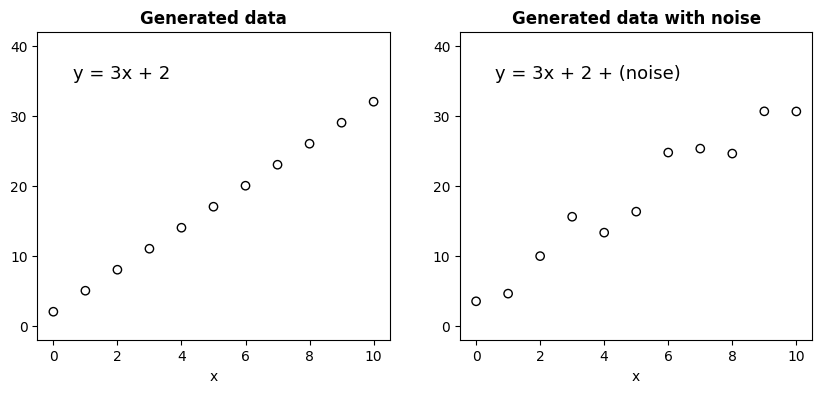

Model #1: a = 3.04, RMSE = 2.32
Model #2: a = 5.25, RMSE = 12.81
Model #3: a = 4.32, RMSE = 7.47


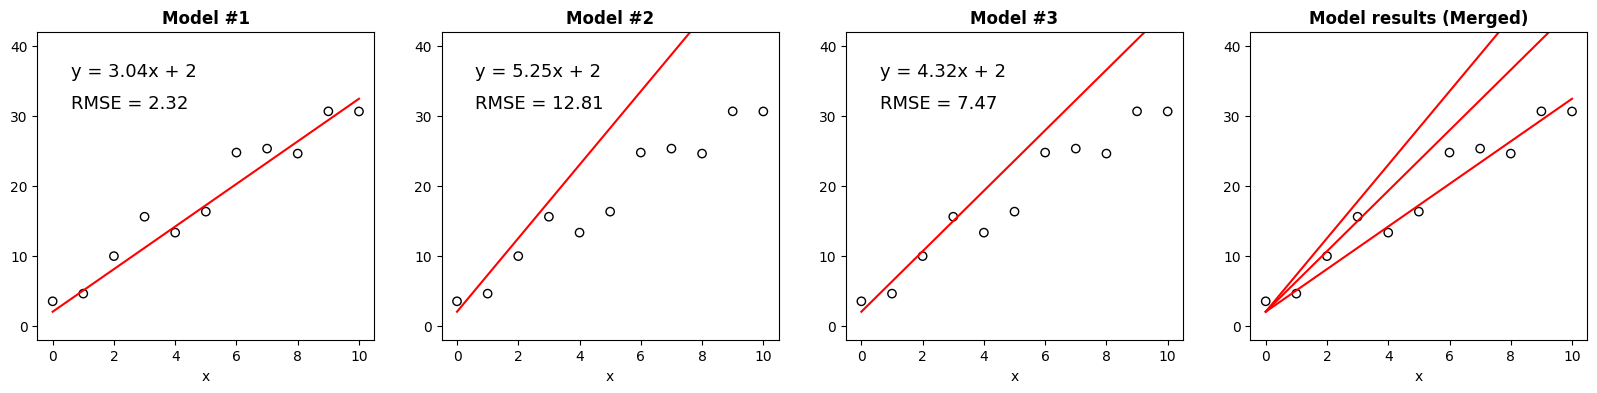

In [103]:
##### Part 1 #####

# Generate training data
np.random.seed(42) # Set seed for reproducibility (Use the same training data generated in the Part 1 again and again)
x = np.arange(11) # x = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
noise = np.random.normal(0, 3, size=len(x)) # Generate random noise: mean 0, standard deviation 3
y_true = 3*x + 2
y_data = y_true + noise # y = 3x + 2 + (noise)

# Draw two plots: y = 3x + 2 and y = 3x + 2 + (noise)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot: y = 3x + 2
axs[0].scatter(x, y_true, facecolors='none', edgecolors='k')
axs[0].set_title('Generated data', fontweight = 'bold')
axs[0].set_xlabel('x')
axs[0].set_xlim(-0.5, 10.5)
axs[0].set_ylim(-2, 42)
axs[0].set_yticks(np.arange(0, 41, 10))
axs[0].text(0.1, 0.85, 'y = 3x + 2', fontsize=13, transform=axs[0].transAxes)

# Plot: y = 3x + 2 + (noise)
axs[1].scatter(x, y_data, facecolors='none', edgecolors='k')
axs[1].set_title('Generated data with noise', fontweight = 'bold')
axs[1].set_xlabel('x')
axs[1].set_ylim(-2, 42)
axs[1].set_yticks(np.arange(0, 41, 10))
axs[1].text(0.1, 0.85, 'y = 3x + 2 + (noise)', fontsize=13, transform=axs[1].transAxes)

plt.show()

# Define objective function (RMSE)
def calc_rmse(y_obs, y_pred):
    return np.sqrt(np.mean((y_obs - y_pred)**2))

# Draw four plots (3 models + 1 merged)
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Randomize parameter 'a' three times in range [0, 10]
a_randoms_1 = np.random.uniform(0, 10, 3)

# Draw 4 plots chaging parameter 'a'
for i in range(3):
    a = a_randoms_1[i]
    y_pred = a*x + 2
    rmse = calc_rmse(y_data, y_pred)

    # Print parameter and RMSE
    print(f"Model #{i+1}: a = {a:.2f}, RMSE = {rmse:.2f}")

    axs[i].scatter(x, y_data, facecolors='none', edgecolors='k')
    axs[i].plot(x, y_pred, color='red')
    axs[i].set_title(f'Model #{i+1}', fontweight = 'bold')
    axs[i].set_xlabel('x')
    axs[i].set_ylim(-2, 42)
    axs[i].set_yticks(np.arange(0, 41, 10))
    axs[i].text(0.1, 0.75, f'y = {a:.2f}x + 2 \nRMSE = {rmse:.2f}', fontsize=13, transform=axs[i].transAxes, linespacing=2)

    # Add to merged plot
    axs[3].plot(x, y_pred, color='red')

axs[3].scatter(x, y_data, facecolors='none', edgecolors='k')
axs[3].set_title('Model results (Merged)', fontweight = 'bold')
axs[3].set_xlabel('x')
axs[3].set_ylim(-2, 42)
axs[3].set_yticks(np.arange(0, 41, 10))

plt.show()


Model #1: a = 3.75, b = 5.99, MSE = 55.91
Model #2: a = 9.51, b = 1.56, MSE = 1407.11
Model #3: a = 7.32, b = 1.56, MSE = 605.73


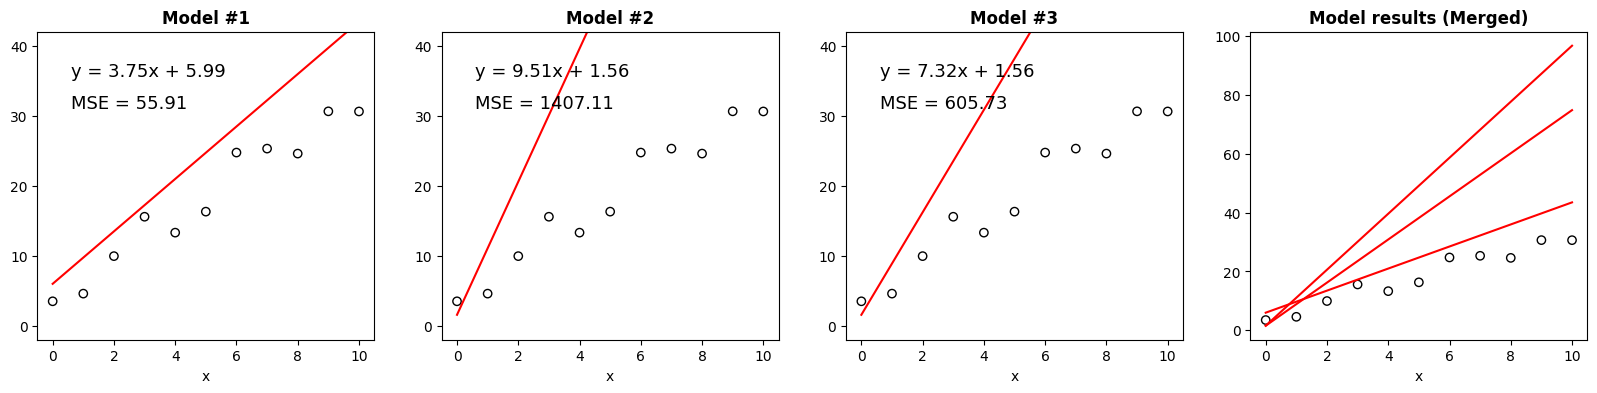

In [104]:
##### Part 2 #####

# Set seed
np.random.seed(42)

# Define objective function (MSE)
def calc_mse(y_obs, y_pred):
    return np.mean((y_obs - y_pred)**2)

# Randomize parameters 'a' and 'b' three times in range [0, 10]
a_randoms_2 = np.random.uniform(0, 10, 3)
b_randoms_2 = np.random.uniform(0, 10, 3)

# Draw four plots
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Draw 4 plots chaging parameter 'a' and 'b'
for i in range(3):
    a = a_randoms_2[i]
    b = b_randoms_2[i]
    y_pred = a*x + b
    mse = calc_mse(y_data, y_pred)

    # Print parameters and MSE
    print(f"Model #{i+1}: a = {a:.2f}, b = {b:.2f}, MSE = {mse:.2f}")

    axs[i].scatter(x, y_data, facecolors='none', edgecolors='k')
    axs[i].plot(x, y_pred, color='red')
    axs[i].set_title(f'Model #{i+1}', fontweight = 'bold')
    axs[i].set_xlabel('x')
    axs[i].set_ylim(-2, 42)
    axs[i].set_yticks(np.arange(0, 41, 10))
    axs[i].text(0.1, 0.75, f'y = {a:.2f}x + {b:.2f}\nMSE = {mse:.2f}', fontsize=13, transform=axs[i].transAxes, linespacing=2)

    # Add to merged plot
    axs[3].plot(x, y_pred, color = 'red')

axs[3].scatter(x, y_data, facecolors='none', edgecolors='k')
axs[3].set_title('Model results (Merged)', fontweight = 'bold')
axs[3].set_xlabel('x')

plt.show()


Optimized a: 3.2, Min RMSE: 2.33


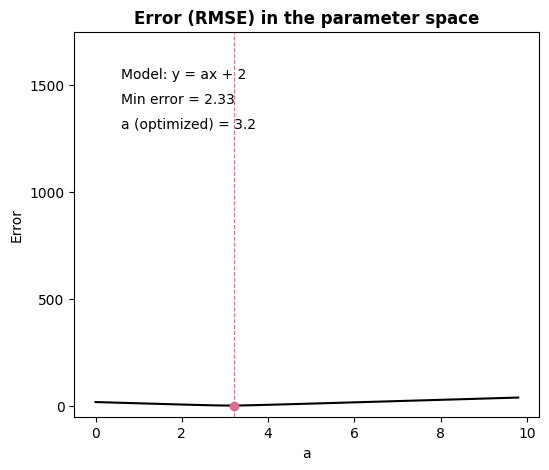

In [105]:
##### Part 3 #####

# Set seed
np.random.seed(42)

# Define parameter space for 'a' in range [0, 10]
ps = np.arange(0, 10, 0.2)
errors = []

# Compute RMSEs across parameter space
for a in ps:
    y_pred = a*x + 2
    errors.append(calc_rmse(y_data, y_pred))

# Find the optimized value of 'a' and minimum error
min_error = min(errors)
optimized_a_index = errors.index(min_error)
optimized_a = ps[optimized_a_index]

print(f"Optimized a: {optimized_a:.1f}, Min RMSE: {min_error:.2f}")

# Draw graph of the error in parameter space
plt.figure(figsize=(6, 5))
plt.plot(ps, errors, color='k')
plt.scatter(optimized_a, min_error, color='palevioletred', zorder=5)
plt.title('Error (RMSE) in the parameter space', fontweight = 'bold')
plt.xlabel('a')
plt.ylabel('Error')
plt.ylim(-50, 1750)
plt.yticks(np.arange(0, 1501, 500))
plt.text(0.1, 0.75, f"Model: y = ax + 2\nMin error = {min_error:.2f}\na (optimized) = {optimized_a:.1f}",
         fontsize=10, transform=plt.gca().transAxes, linespacing=2)
plt.axvline(x=optimized_a, color='palevioletred', linestyle='--', linewidth=0.8)

plt.show()


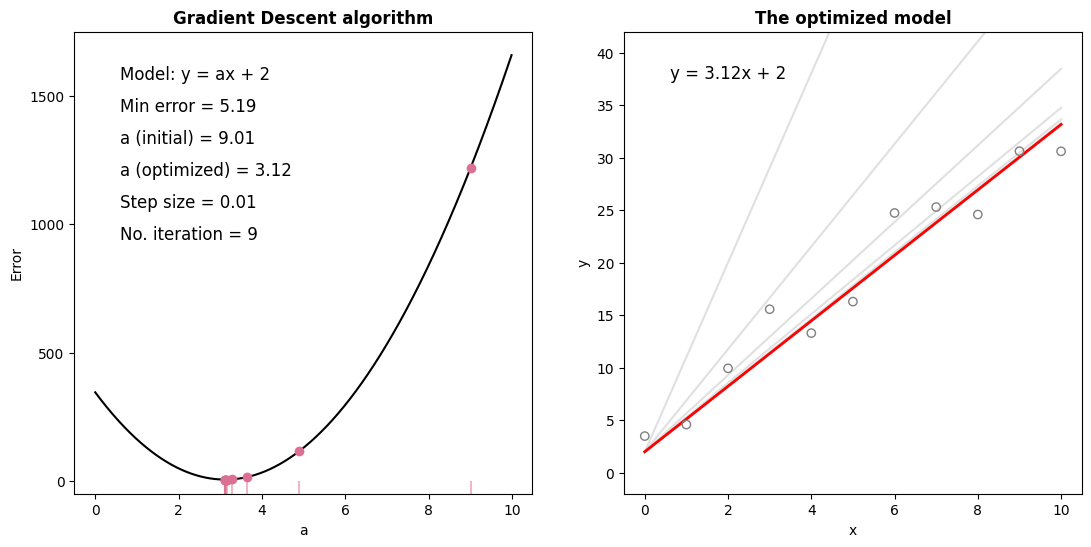

In [106]:
##### Part 4 #####

# Set seed
np.random.seed(42)

# Define objective function (MSE)
def objective_function(a):
    y_pred = a*x + 2
    return np.mean((y_data - y_pred)**2)

# Define derivative function for MSE
def derivative_function(a):
    y_pred = a*x + 2
    # Derivative of MSE with respect to 'a'
    return np.mean(-2 * x * (y_data - y_pred))

# Parameter optimization settings
n_iter = 100
step_size = 0.01 # Learning rate
slope_threshold = 0.01

# Choose a starting point randomly
a_current = 9.01 # Initial value used in example
a_history = [a_current]
error_history = [objective_function(a_current)]

# Gradient descent loop
for i in range(n_iter):
    gradient = derivative_function(a_current)

    # Check stop condition
    if abs(gradient) < slope_threshold:
        break

    # Make a move in the negative direction
    a_current = a_current - step_size * gradient
    a_history.append(a_current)
    error_history.append(objective_function(a_current))

# Plot CGS result with Gradient Descent path
ps_gd = np.arange(0, 10, 0.01)
errors_gd = [objective_function(val) for val in ps_gd]

fig, axs = plt.subplots(1, 2, figsize=(13, 6))

axs[0].plot(ps_gd, errors_gd, color='k')
axs[0].scatter(a_history, error_history, color='palevioletred', zorder=5)
axs[0].set_ylim(-50, 1750)
axs[0].vlines(x=a_history, ymin=-50, ymax=0, color='palevioletred', alpha=0.5, linewidth=1.5) # Draw rugs
axs[0].set_title('Gradient Descent algorithm', fontweight = 'bold')
axs[0].set_xlabel('a'); axs[0].set_ylabel('Error')
text_str = f"Model: y = ax + 2\nMin error = {error_history[-1]:.2f}\na (initial) = {a_history[0]:.2f}\na (optimized) = {a_current:.2f}\nStep size = {step_size}\nNo. iteration = {len(a_history)-1}"
axs[0].text(0.1, 0.55, text_str, fontsize=12,  transform=axs[0].transAxes, linespacing=2)
axs[0].set_yticks(np.arange(0, 1501, 500))

# Plot training data and all models during GD optimization
axs[1].scatter(x, y_data, facecolors='none', edgecolors='gray', zorder=10)
for a_val in a_history:
    axs[1].plot(x, a_val * x + 2, color='lightgray', alpha=0.7)

# Plot the final optimized model in red
axs[1].plot(x, a_current * x + 2, color='red', linewidth=2)
axs[1].text(0.1, 0.9, f"y = {a_current:.2f}x + 2", fontsize=12,  transform=axs[1].transAxes, linespacing=2)
axs[1].set_title('The optimized model', fontweight = 'bold')
axs[1].set_xlabel('x'); axs[1].set_ylabel('y')
axs[1].set_ylim(-2, 42)

plt.show()
